In [44]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from mlxtend.plotting import plot_decision_regions
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [45]:
df = pd.read_csv('Social_Network_Ads.csv')

In [46]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [48]:
df.duplicated().sum()

np.int64(33)

In [49]:
df1= df.drop_duplicates().reset_index(drop=True)

In [50]:
print(df1.duplicated().sum())
print(f'Shape of the dataset after droppoing duplicate values is ',df1.shape)

0
Shape of the dataset after droppoing duplicate values is  (367, 3)


In [51]:
print(df1['Purchased'].value_counts(normalize=True))

Purchased
0    0.623978
1    0.376022
Name: proportion, dtype: float64


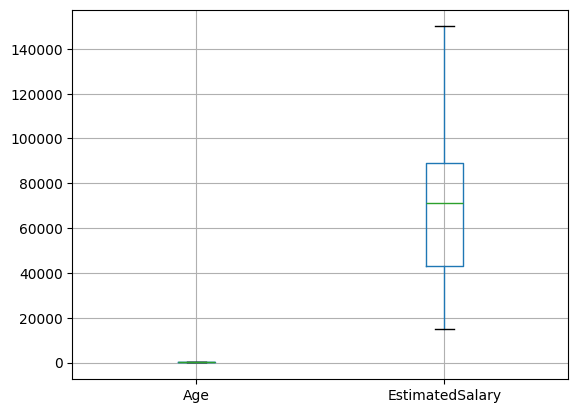

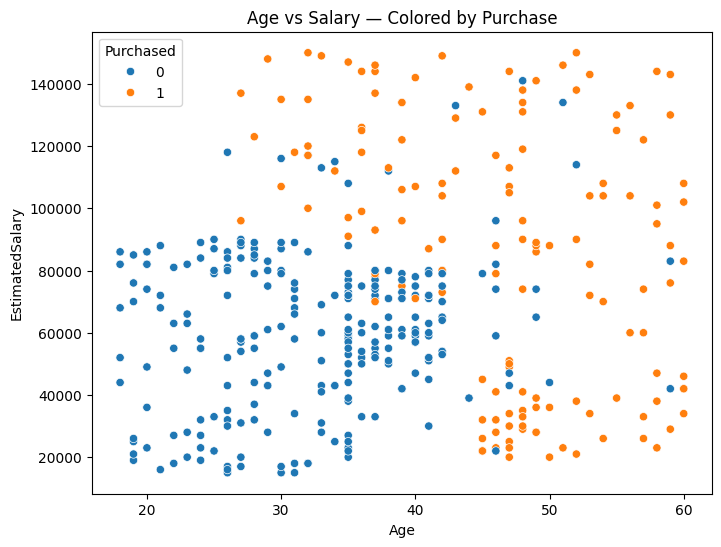

In [52]:
df1.boxplot(column=['Age', 'EstimatedSalary'])
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Age', y='EstimatedSalary', hue='Purchased')
plt.title('Age vs Salary — Colored by Purchase')
plt.show()

In [53]:
df1['weights']=1/df1.shape[0]

In [54]:
df1

,Age,EstimatedSalary,Purchased,weights
0,19,19000,0,0.002725
1,35,20000,0,0.002725
2,26,43000,0,0.002725
3,27,57000,0,0.002725
4,19,76000,0,0.002725
...,...,...,...,...
362,46,41000,1,0.002725
363,51,23000,1,0.002725
364,50,20000,1,0.002725
365,36,33000,0,0.002725


In [55]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [56]:
x= df1.iloc[:,0:2].values
y= df1.iloc[:,2].values

In [57]:
dt1.fit(x,y)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

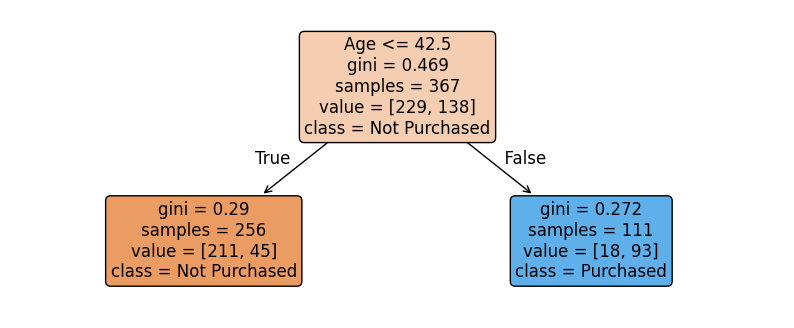

In [58]:
plt.figure(figsize=(10, 4))
plot_tree(dt1, feature_names=['Age', 'EstimatedSalary'], class_names=['Not Purchased', 'Purchased'], filled=True, rounded=True, fontsize=12)
plt.show()

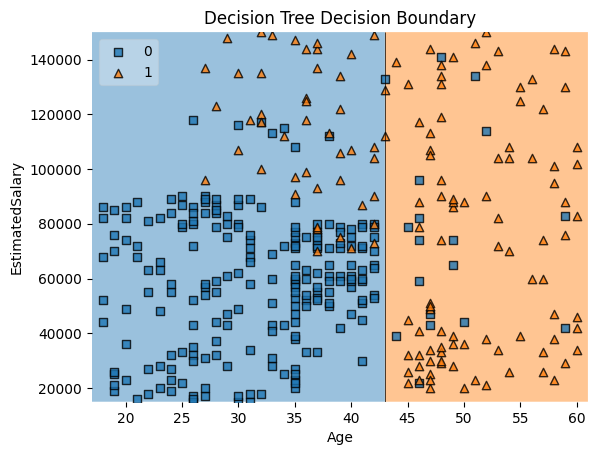

In [59]:
plot_decision_regions(x,y,clf=dt1,legend=2)
plt.xlabel('Age')
plt.ylabel('EstimatedSalary')
plt.title('Decision Tree Decision Boundary')
plt.show()

In [60]:
df1['y_pred']=dt1.predict(x)

In [61]:
df1

,Age,EstimatedSalary,Purchased,weights,y_pred
0,19,19000,0,0.002725,0
1,35,20000,0,0.002725,0
2,26,43000,0,0.002725,0
3,27,57000,0,0.002725,0
4,19,76000,0,0.002725,0
...,...,...,...,...,...
362,46,41000,1,0.002725,1
363,51,23000,1,0.002725,1
364,50,20000,1,0.002725,1
365,36,33000,0,0.002725,0


In [62]:
def calculate_error(df):
    error = df.loc[df['Purchased'] != df['y_pred'], 'weights'].sum()
    return error

In [63]:
error_1 = calculate_error(df1)
print(error_1)

0.17166212534059952


In [64]:
def calculate_model_weight(error):
    
    return .5*np.log((1-error)/(error+.00000001))

In [65]:
alpha_1=calculate_model_weight(error_1)
alpha_1

np.float64(0.786946458380361)

Step 4 : Update Weights

In [66]:
def update_row_weights(row,alpha):
    if row['Purchased']==row['y_pred']:
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)

In [67]:
df1['updated_weights'] = df1.apply(lambda row: update_row_weights(row, alpha_1), axis=1)

In [68]:
df1

,Age,EstimatedSalary,Purchased,weights,y_pred,updated_weights
0,19,19000,0,0.002725,0,0.00124
1,35,20000,0,0.002725,0,0.00124
2,26,43000,0,0.002725,0,0.00124
3,27,57000,0,0.002725,0,0.00124
4,19,76000,0,0.002725,0,0.00124
...,...,...,...,...,...,...
362,46,41000,1,0.002725,1,0.00124
363,51,23000,1,0.002725,1,0.00124
364,50,20000,1,0.002725,1,0.00124
365,36,33000,0,0.002725,0,0.00124


In [69]:
def normalize_weights(df):
    df['normalized_weights'] = df['updated_weights'] / df['updated_weights'].sum()
    return df

In [70]:
df1 = normalize_weights(df1)
df1

,Age,EstimatedSalary,Purchased,weights,y_pred,updated_weights,normalized_weights
0,19,19000,0,0.002725,0,0.00124,0.001645
1,35,20000,0,0.002725,0,0.00124,0.001645
2,26,43000,0,0.002725,0,0.00124,0.001645
3,27,57000,0,0.002725,0,0.00124,0.001645
4,19,76000,0,0.002725,0,0.00124,0.001645
...,...,...,...,...,...,...,...
362,46,41000,1,0.002725,1,0.00124,0.001645
363,51,23000,1,0.002725,1,0.00124,0.001645
364,50,20000,1,0.002725,1,0.00124,0.001645
365,36,33000,0,0.002725,0,0.00124,0.001645


In [71]:
df1['normalized_weights'].sum()

np.float64(1.0)

In [72]:
def calculate_cumsum(df):
    df['cumsum_upper'] = np.cumsum(df['normalized_weights'])
    df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']
    return df

In [73]:
df1 = calculate_cumsum(df1)

In [74]:
def show_df(df):
    return df[['Age', 'EstimatedSalary', 'Purchased', 'weights', 
               'y_pred', 'updated_weights', 'cumsum_lower', 'cumsum_upper']]

In [75]:
show_df(df1)

,Age,EstimatedSalary,Purchased,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,19,19000,0,0.002725,0,0.00124,0.000000,0.001645
1,35,20000,0,0.002725,0,0.00124,0.001645,0.003289
2,26,43000,0,0.002725,0,0.00124,0.003289,0.004934
3,27,57000,0,0.002725,0,0.00124,0.004934,0.006579
4,19,76000,0,0.002725,0,0.00124,0.006579,0.008224
...,...,...,...,...,...,...,...,...
362,46,41000,1,0.002725,1,0.00124,0.991776,0.993421
363,51,23000,1,0.002725,1,0.00124,0.993421,0.995066
364,50,20000,1,0.002725,1,0.00124,0.995066,0.996711
365,36,33000,0,0.002725,0,0.00124,0.996711,0.998355


In [76]:
def create_new_dataset(df):
    indices=[]

    for i in range(df.shape[0]):
        a=np.random.random()
        for index,row in df.iterrows():
            if row['cumsum_upper']>a and a>row['cumsum_lower']:
                indices.append(index)
    return indices            

In [77]:
index_values_1 = create_new_dataset(df1)
len(index_values_1)

367

In [78]:
df2 = df1.iloc[index_values_1,[0,1,2,3]]

In [79]:
df2

,Age,EstimatedSalary,Purchased,weights
240,50,44000,0,0.002725
132,30,107000,1,0.002725
241,52,90000,1,0.002725
314,35,79000,0,0.002725
294,39,79000,0,0.002725
...,...,...,...,...
150,29,75000,0,0.002725
7,32,150000,1,0.002725
138,34,25000,0,0.002725
6,27,84000,0,0.002725


In [80]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [81]:
x = df2.iloc[:,0:2].values
y = df2.iloc[:,2].values

In [82]:
dt2.fit(x,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

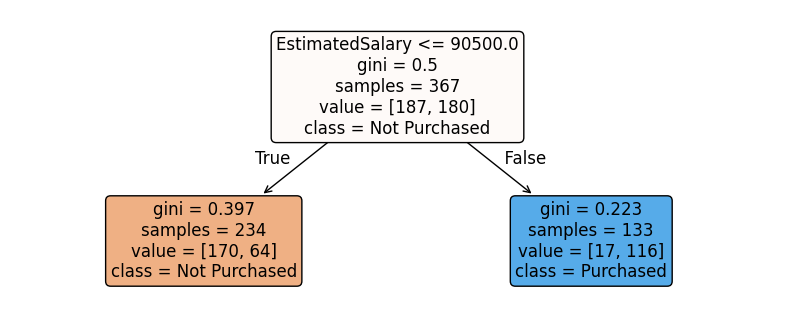

In [83]:
plt.figure(figsize=(10, 4))
plot_tree(dt2, feature_names=['Age', 'EstimatedSalary'], class_names=['Not Purchased', 'Purchased'], filled=True, rounded=True, fontsize=12)
plt.show()

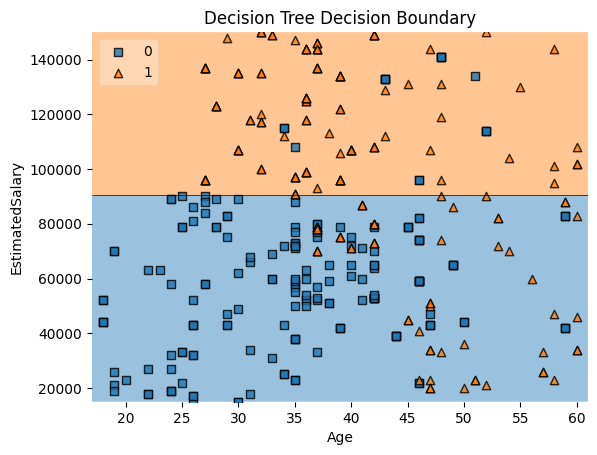

In [84]:
plot_decision_regions(x,y,clf=dt2,legend=2)
plt.xlabel('Age')
plt.ylabel('EstimatedSalary')
plt.title('Decision Tree Decision Boundary')
plt.show()

In [85]:
df2['y_pred']=dt2.predict(x)

In [86]:
df2

,Age,EstimatedSalary,Purchased,weights,y_pred
240,50,44000,0,0.002725,0
132,30,107000,1,0.002725,1
241,52,90000,1,0.002725,0
314,35,79000,0,0.002725,0
294,39,79000,0,0.002725,0
...,...,...,...,...,...
150,29,75000,0,0.002725,0
7,32,150000,1,0.002725,1
138,34,25000,0,0.002725,0
6,27,84000,0,0.002725,0


In [87]:
error_2= calculate_error(df2)

In [88]:
alpha_2 = calculate_model_weight(error_2)
alpha_2

np.float64(0.6307713054193866)

In [89]:
df2['updated_weights'] = df2.apply(lambda row: update_row_weights(row, alpha_2),axis=1)

In [90]:
df2

,Age,EstimatedSalary,Purchased,weights,y_pred,updated_weights
240,50,44000,0,0.002725,0,0.00145
132,30,107000,1,0.002725,1,0.00145
241,52,90000,1,0.002725,0,0.00512
314,35,79000,0,0.002725,0,0.00145
294,39,79000,0,0.002725,0,0.00145
...,...,...,...,...,...,...
150,29,75000,0,0.002725,0,0.00145
7,32,150000,1,0.002725,1,0.00145
138,34,25000,0,0.002725,0,0.00145
6,27,84000,0,0.002725,0,0.00145


In [91]:
df2 = normalize_weights(df2)
df2

,Age,EstimatedSalary,Purchased,weights,y_pred,updated_weights,normalized_weights
240,50,44000,0,0.002725,0,0.00145,0.001748
132,30,107000,1,0.002725,1,0.00145,0.001748
241,52,90000,1,0.002725,0,0.00512,0.006173
314,35,79000,0,0.002725,0,0.00145,0.001748
294,39,79000,0,0.002725,0,0.00145,0.001748
...,...,...,...,...,...,...,...
150,29,75000,0,0.002725,0,0.00145,0.001748
7,32,150000,1,0.002725,1,0.00145,0.001748
138,34,25000,0,0.002725,0,0.00145,0.001748
6,27,84000,0,0.002725,0,0.00145,0.001748


In [92]:
df2['normalized_weights'].sum()

np.float64(0.9999999999999999)

In [93]:
calculate_cumsum(df2)

,Age,EstimatedSalary,Purchased,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
240,50,44000,0,0.002725,0,0.00145,0.001748,0.001748,0.000000
132,30,107000,1,0.002725,1,0.00145,0.001748,0.003497,0.001748
241,52,90000,1,0.002725,0,0.00512,0.006173,0.009669,0.003497
314,35,79000,0,0.002725,0,0.00145,0.001748,0.011418,0.009669
294,39,79000,0,0.002725,0,0.00145,0.001748,0.013166,0.011418
...,...,...,...,...,...,...,...,...,...
150,29,75000,0,0.002725,0,0.00145,0.001748,0.993007,0.991259
7,32,150000,1,0.002725,1,0.00145,0.001748,0.994755,0.993007
138,34,25000,0,0.002725,0,0.00145,0.001748,0.996503,0.994755
6,27,84000,0,0.002725,0,0.00145,0.001748,0.998252,0.996503


In [94]:
show_df(df2)

,Age,EstimatedSalary,Purchased,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
240,50,44000,0,0.002725,0,0.00145,0.000000,0.001748
132,30,107000,1,0.002725,1,0.00145,0.001748,0.003497
241,52,90000,1,0.002725,0,0.00512,0.003497,0.009669
314,35,79000,0,0.002725,0,0.00145,0.009669,0.011418
294,39,79000,0,0.002725,0,0.00145,0.011418,0.013166
...,...,...,...,...,...,...,...,...
150,29,75000,0,0.002725,0,0.00145,0.991259,0.993007
7,32,150000,1,0.002725,1,0.00145,0.993007,0.994755
138,34,25000,0,0.002725,0,0.00145,0.994755,0.996503
6,27,84000,0,0.002725,0,0.00145,0.996503,0.998252


In [95]:
index_values_2 = create_new_dataset(df2)

In [96]:
df3= df2.iloc[index_values_2,[0,1,2,3]]
df3

,Age,EstimatedSalary,Purchased,weights
149,46,59000,0,0.002725
228,38,59000,0,0.002725
350,58,23000,1,0.002725
236,44,39000,0,0.002725
329,36,99000,1,0.002725
...,...,...,...,...
5,27,58000,0,0.002725
215,36,126000,1,0.002725
274,37,77000,0,0.002725
295,39,75000,1,0.002725


In [97]:
dt3 = DecisionTreeClassifier(max_depth=1)
x= df3.iloc[:,0:2].values
y= df3.iloc[:,2].values
dt3.fit(x,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

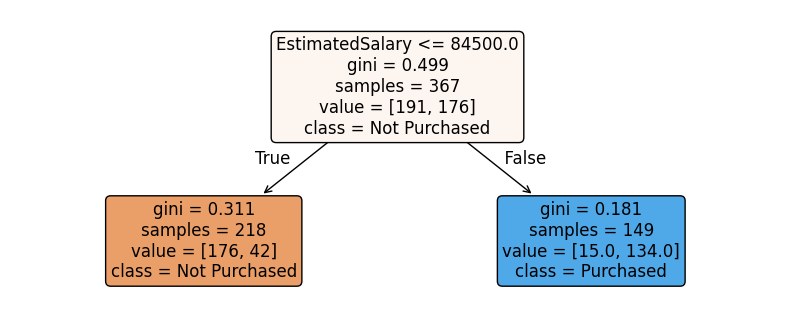

In [98]:
plt.figure(figsize=(10, 4))
plot_tree(dt3, feature_names=['Age', 'EstimatedSalary'], class_names=['Not Purchased', 'Purchased'], filled=True, rounded=True, fontsize=12)
plt.show()

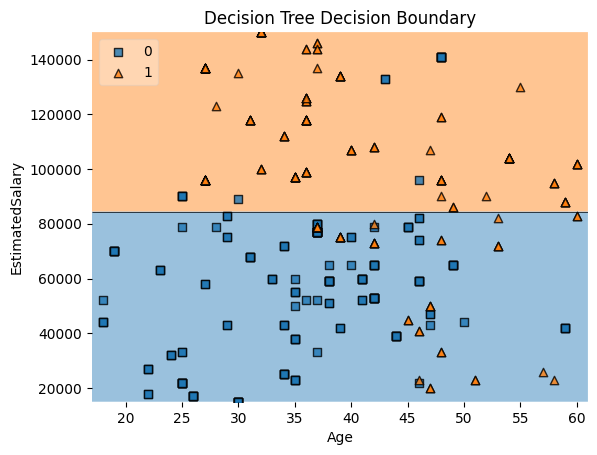

In [99]:
plot_decision_regions(x,y,clf=dt3,legend=2)
plt.xlabel('Age')
plt.ylabel('EstimatedSalary')
plt.title('Decision Tree Decision Boundary')
plt.show()

In [100]:
df3['y_pred']=dt3.predict(x)
df3

,Age,EstimatedSalary,Purchased,weights,y_pred
149,46,59000,0,0.002725,0
228,38,59000,0,0.002725,0
350,58,23000,1,0.002725,0
236,44,39000,0,0.002725,0
329,36,99000,1,0.002725,1
...,...,...,...,...,...
5,27,58000,0,0.002725,0
215,36,126000,1,0.002725,1
274,37,77000,0,0.002725,0
295,39,75000,1,0.002725,0
